import libraries

In [2]:
import argparse
from pathlib import Path
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import torch
from torch.utils.data import Dataset
from PIL import Image


load data

In [178]:
mass_df = pd.read_csv(r"C:\Users\user\Desktop\breast_cancer_cnn_app\k_CBIS-DDSM\mass_case(with_jpg_img).csv")
calc_df = pd.read_csv(r"C:\Users\user\Desktop\breast_cancer_cnn_app\k_CBIS-DDSM\calc_case(with_jpg_img).csv")

In [179]:
mass_df.shape

(1696, 14)

In [121]:
mass_df.columns.tolist()

['patient_id',
 'breast_density',
 'left or right breast',
 'image view',
 'abnormality id',
 'abnormality type',
 'mass shape',
 'mass margins',
 'assessment',
 'pathology',
 'subtlety',
 'jpg_fullMammo_img_path',
 'jpg_crop_img_path',
 'jpg_ROI_img_path']

In [180]:
mass_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,jpg_fullMammo_img_path,jpg_crop_img_path,jpg_ROI_img_path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,jpg_img/Mass_Training_P_00001_LEFT_CC-1.3.6.1....,jpg_img/Mass_Training_P_00001_LEFT_CC_1-1.3.6....,jpg_img/Mass_Training_P_00001_LEFT_CC_1-1.3.6....
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,jpg_img/Mass_Training_P_00001_LEFT_MLO-1.3.6.1...,jpg_img/Mass_Training_P_00001_LEFT_MLO_1-1.3.6...,jpg_img/Mass_Training_P_00001_LEFT_MLO_1-1.3.6...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,jpg_img/Mass_Training_P_00004_LEFT_CC-1.3.6.1....,jpg_img/Mass_Training_P_00004_LEFT_CC_1-1.3.6....,jpg_img/Mass_Training_P_00004_LEFT_CC_1-1.3.6....
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,jpg_img/Mass_Training_P_00004_LEFT_MLO-1.3.6.1...,jpg_img/Mass_Training_P_00004_LEFT_MLO_1-1.3.6...,jpg_img/Mass_Training_P_00004_LEFT_MLO_1-1.3.6...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,jpg_img/Mass_Training_P_00004_RIGHT_MLO-1.3.6....,jpg_img/Mass_Training_P_00004_RIGHT_MLO_1-1.3....,jpg_img/Mass_Training_P_00004_RIGHT_MLO_1-1.3....


In [181]:
calc_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,jpg_fullMammo_img_path,jpg_crop_img_path,jpg_ROI_img_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,jpg_img/Calc_Training_P_00005_RIGHT_CC-1.3.6.1...,jpg_img/Calc_Training_P_00005_RIGHT_CC_1-1.3.6...,jpg_img/Calc_Training_P_00005_RIGHT_CC_1-1.3.6...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,jpg_img/Calc_Training_P_00005_RIGHT_MLO-1.3.6....,jpg_img/Calc_Training_P_00005_RIGHT_MLO_1-1.3....,jpg_img/Calc_Training_P_00005_RIGHT_MLO_1-1.3....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,jpg_img/Calc_Training_P_00007_LEFT_CC-1.3.6.1....,jpg_img/Calc_Training_P_00007_LEFT_CC_1-1.3.6....,jpg_img/Calc_Training_P_00007_LEFT_CC_1-1.3.6....
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,jpg_img/Calc_Training_P_00007_LEFT_MLO-1.3.6.1...,jpg_img/Calc_Training_P_00007_LEFT_MLO_1-1.3.6...,jpg_img/Calc_Training_P_00007_LEFT_MLO_1-1.3.6...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,jpg_img/Calc_Training_P_00008_LEFT_CC-1.3.6.1....,jpg_img/Calc_Training_P_00008_LEFT_CC_1-1.3.6....,jpg_img/Calc_Training_P_00008_LEFT_CC_1-1.3.6....


In [182]:
()

()

In [183]:
mass_df["pathology"].describe()

count          1696
unique            3
top       MALIGNANT
freq            784
Name: pathology, dtype: object

In [184]:
mass_df["pathology"].value_counts()

pathology
MALIGNANT                  784
BENIGN                     771
BENIGN_WITHOUT_CALLBACK    141
Name: count, dtype: int64

In [185]:
calc_df["pathology"].value_counts()

pathology
MALIGNANT                  673
BENIGN                     658
BENIGN_WITHOUT_CALLBACK    541
Name: count, dtype: int64

In [186]:
print("Mass dataset:")
print(mass_df["pathology"].value_counts())

print("\nCalcification dataset:")
print(calc_df["pathology"].value_counts())

Mass dataset:
pathology
MALIGNANT                  784
BENIGN                     771
BENIGN_WITHOUT_CALLBACK    141
Name: count, dtype: int64

Calcification dataset:
pathology
MALIGNANT                  673
BENIGN                     658
BENIGN_WITHOUT_CALLBACK    541
Name: count, dtype: int64


lets inspect the image path

In [187]:
mass_df["jpg_fullMammo_img_path"].head()

0    jpg_img/Mass_Training_P_00001_LEFT_CC-1.3.6.1....
1    jpg_img/Mass_Training_P_00001_LEFT_MLO-1.3.6.1...
2    jpg_img/Mass_Training_P_00004_LEFT_CC-1.3.6.1....
3    jpg_img/Mass_Training_P_00004_LEFT_MLO-1.3.6.1...
4    jpg_img/Mass_Training_P_00004_RIGHT_MLO-1.3.6....
Name: jpg_fullMammo_img_path, dtype: str

In [188]:
calc_df["jpg_fullMammo_img_path"].head()

0    jpg_img/Calc_Training_P_00005_RIGHT_CC-1.3.6.1...
1    jpg_img/Calc_Training_P_00005_RIGHT_MLO-1.3.6....
2    jpg_img/Calc_Training_P_00007_LEFT_CC-1.3.6.1....
3    jpg_img/Calc_Training_P_00007_LEFT_MLO-1.3.6.1...
4    jpg_img/Calc_Training_P_00008_LEFT_CC-1.3.6.1....
Name: jpg_fullMammo_img_path, dtype: str

In [189]:
label_map = {
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1
}

In [190]:
mass_df["label"] = mass_df["pathology"].map(label_map)
calc_df["label"] = calc_df["pathology"].map(label_map)

In [191]:
mass_df[["pathology", "label"]].head(10)

,pathology,label
0,MALIGNANT,1
1,MALIGNANT,1
2,BENIGN,0
3,BENIGN,0
4,BENIGN,0
5,MALIGNANT,1
6,MALIGNANT,1
7,MALIGNANT,1
8,BENIGN,0
9,BENIGN,0


combining mass and cal to form one dataframe

In [192]:
data_df = pd.concat(
    [mass_df, calc_df],
    ignore_index=True
)

In [193]:
data_df.shape

(3568, 18)

In [194]:
data_df['label'].value_counts()

label
0    2111
1    1457
Name: count, dtype: int64

pytorch dataset

In [196]:
class MammogramDataset(Dataset):

    def __init__(self, dataframe, image_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.loc[
            index, "jpg_fullMammo_img_path"
        ]

        label = self.dataframe.loc[
            index, "label"
        ]

        image_path = self.image_root / image_path

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

In [197]:
from pathlib import Path

dataset_root = Path(
    r"C:\Users\user\Desktop\breast_cancer_cnn_app\k_CBIS-DDSM"
)

print(dataset_root)
print(dataset_root.exists())

C:\Users\user\Desktop\breast_cancer_cnn_app\k_CBIS-DDSM
True


create the dataset

In [198]:
dataset = MammogramDataset(
    data_df,
    dataset_root
)

size of the dataset

In [199]:
len(dataset)

3568

inspect one sample

In [200]:
from pathlib import Path

image, label = dataset[0]

print(image)
print(label)

<PIL.Image.Image image mode=L size=3024x4808 at 0x2411F9A5D50>
1


view one image sample

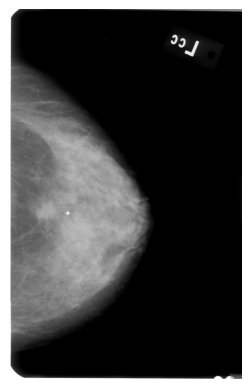

In [201]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

image transformation

In [202]:
from torchvision import transforms

In [203]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

validation set transformation

In [204]:
val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

test the transformed image

In [205]:
transformed_image = train_transform(image)

print(transformed_image.shape)

torch.Size([1, 128, 128])


In [206]:
from sklearn.model_selection import GroupShuffleSplit

separate out the test set

In [207]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

In [208]:
train_val_idx, test_idx = next(
    gss.split(
        data_df,
        groups=data_df["patient_id"]
    )
)

creating two dataframes

In [150]:
train_val_df = data_df.iloc[train_val_idx].copy()
test_df = data_df.iloc[test_idx].copy()

In [151]:
print("Train + validation:", len(train_val_df))
print("Test:", len(test_df))

Train + validation: 2874
Test: 694


splitting train and validation set

In [209]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

In [210]:
train_idx, val_idx = next(
    gss_val.split(
        train_val_df,
        groups=train_val_df["patient_id"]
    )
)

In [211]:
train_df = train_val_df.iloc[train_idx].copy()
val_df = train_val_df.iloc[val_idx].copy()

In [212]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

checking for leakgae and overlap

In [213]:
print("Train/Val overlap:", len(train_patients & val_patients))
print("Train/Test overlap:", len(train_patients & test_patients))
print("Val/Test overlap:", len(val_patients & test_patients))

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


In [214]:
print("TRAIN")
print(train_df["pathology"].value_counts())

print("\nVALIDATION")
print(val_df["pathology"].value_counts())

print("\nTEST")
print(test_df["pathology"].value_counts())

TRAIN
pathology
MALIGNANT                  970
BENIGN                     882
BENIGN_WITHOUT_CALLBACK    463
Name: count, dtype: int64

VALIDATION
pathology
BENIGN                     237
MALIGNANT                  223
BENIGN_WITHOUT_CALLBACK     99
Name: count, dtype: int64

TEST
pathology
BENIGN                     310
MALIGNANT                  264
BENIGN_WITHOUT_CALLBACK    120
Name: count, dtype: int64


In [215]:
print("TRAIN")
print(train_df["label"].value_counts())

print("\nVALIDATION")
print(val_df["label"].value_counts())

print("\nTEST")
print(test_df["label"].value_counts())

TRAIN
label
0    1345
1     970
Name: count, dtype: int64

VALIDATION
label
0    336
1    223
Name: count, dtype: int64

TEST
label
0    430
1    264
Name: count, dtype: int64


In [216]:
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2315
Validation: 559
Test: 694


checking for patient leakage

In [217]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])
test_patients = set(test_df["patient_id"])

print(
    "Train/Val overlap:",
    len(train_patients & val_patients)
)

print(
    "Train/Test overlap:",
    len(train_patients & test_patients)
)

print(
    "Val/Test overlap:",
    len(val_patients & test_patients)
)

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


test transform

In [218]:
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [219]:
#train dataset
train_dataset = MammogramDataset(
    train_df,
    dataset_root,
    transform=train_transform
)

In [220]:
#validation dataset
val_dataset = MammogramDataset(
    val_df,
    dataset_root,
    transform=val_transform
)

In [221]:
#test dataset
test_dataset = MammogramDataset(
    test_df,
    dataset_root,
    transform=test_transform
)

creating dataloaders

In [222]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [223]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [224]:
test_loader = DataLoader(
   test_dataset,
    batch_size=32,
    shuffle=False
)

check one batch

In [225]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 1, 128, 128])
Labels: torch.Size([32])


In [244]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


class weight

In [245]:
print(train_df["label"].value_counts())
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:", class_weights)

label
0    1345
1     970
Name: count, dtype: int64
Class weights: tensor([0.8606, 1.1933])


In [248]:
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.8606, 1.1933])


CNN

In [226]:
import torch.nn as nn

create the cnn class

In [240]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CNN_V2(nn.Module):

    def __init__(self):
        super(CNN_V2, self).__init__()

        # Convolution Block 1
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Convolution Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Convolution Block 3
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        # Pooling layer
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(
            128 * 16 * 16,
            256
        )

        self.dropout = nn.Dropout(0.5)

        self.fc2 = nn.Linear(
            256,
            2
        )


    def forward(self, x):

        # Block 1
        x = self.pool(
            F.relu(self.conv1(x))
        )

        # Block 2
        x = self.pool(
            F.relu(self.conv2(x))
        )

        # Block 3
        x = self.pool(
            F.relu(self.conv3(x))
        )

        # Flatten
        x = torch.flatten(x, 1)

        # Fully Connected Layer
        x = F.relu(self.fc1(x))

        # Dropout
        x = self.dropout(x)

        # Output Layer
        x = self.fc2(x)

        return x

In [261]:
model = CNN_V2().to(device)

print(model)

CNN_V2(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


LOSS FUNCTION

In [269]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print(criterion)

CrossEntropyLoss()


OPTIMIZER

In [270]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(optimizer)


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [264]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 128, 128])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


TRAIN THE MODEL

In [271]:
num_epochs = 10
patience = 3
best_val_accuracy = 0.0
best_val_loss = float("inf")
best_model_state = None
counter = 0


RUN TRAINING LOOP

In [272]:
for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # =========================
    # PRINT
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("Best model saved.")

    else:

        counter += 1

        print(
            f"No improvement. "
            f"Patience: {counter}/{patience}"
        )

        if counter >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 0.6917 Train Acc: 52.87% Val Loss: 0.7148 Val Acc: 43.83%
Best model saved.
Epoch [2/10] Train Loss: 0.6939 Train Acc: 50.84% Val Loss: 0.6920 Val Acc: 57.25%
Best model saved.
Epoch [3/10] Train Loss: 0.6878 Train Acc: 54.86% Val Loss: 0.6848 Val Acc: 61.00%
Best model saved.
Epoch [4/10] Train Loss: 0.6888 Train Acc: 56.85% Val Loss: 0.6915 Val Acc: 44.72%
No improvement. Patience: 1/3
Epoch [5/10] Train Loss: 0.6770 Train Acc: 59.96% Val Loss: 0.6687 Val Acc: 57.42%
No improvement. Patience: 2/3
Epoch [6/10] Train Loss: 0.6640 Train Acc: 61.34% Val Loss: 0.6533 Val Acc: 62.43%
Best model saved.
Epoch [7/10] Train Loss: 0.6460 Train Acc: 62.25% Val Loss: 0.6603 Val Acc: 60.64%
No improvement. Patience: 1/3
Epoch [8/10] Train Loss: 0.6484 Train Acc: 62.03% Val Loss: 0.6493 Val Acc: 61.18%
No improvement. Patience: 2/3
Epoch [9/10] Train Loss: 0.6399 Train Acc: 63.97% Val Loss: 0.6480 Val Acc: 62.61%
Best model saved.
Epoch [10/10] Train Loss: 0.6371 Train Acc:

load the best model

In [273]:
model.load_state_dict(best_model_state)

print("Best V2 model loaded.")
print("Best validation accuracy:", best_val_accuracy)

Best V2 model loaded.
Best validation accuracy: 62.61180679785331


In [274]:
model.eval()

val_correct = 0
val_total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        val_total += labels.size(0)
        val_correct += (predictions == labels).sum().item()

final_val_accuracy = 100 * val_correct / val_total

print("Final V2 Validation Accuracy:", final_val_accuracy)

Final V2 Validation Accuracy: 62.61180679785331


to test on test

In [275]:
model.load_state_dict(best_model_state)

print("Best V2 model loaded.")
print("Best validation accuracy:", best_val_accuracy)

Best V2 model loaded.
Best validation accuracy: 62.61180679785331


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

test_accuracy = (
    100 *
    sum(
        p == y
        for p, y in zip(
            all_test_predictions,
            all_test_labels
        )
    )
    / len(all_test_labels)
)

print("CNN V2 Test Accuracy:", test_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_test_labels,
        all_test_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions
    )
)

calculate class weight

In [ ]:
class_counts = train_df["label"].value_counts().sort_index()

print(class_counts)

label
0    1345
1     970
Name: count, dtype: int64


In [277]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )

test_accuracy = (
    100 *
    sum(
        p == y
        for p, y in zip(
            all_test_predictions,
            all_test_labels
        )
    )
    / len(all_test_labels)
)

print("CNN V2 Test Accuracy:", test_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_test_labels,
        all_test_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions
    )
)

CNN V2 Test Accuracy: 64.98559077809799

Confusion Matrix:
[[266 164]
 [ 79 185]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69       430
           1       0.53      0.70      0.60       264

    accuracy                           0.65       694
   macro avg       0.65      0.66      0.65       694
weighted avg       0.68      0.65      0.65       694



In [278]:
class CNN_V3(nn.Module):

    def __init__(self):
        super(CNN_V3, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(
            64, 128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)

        # Pooling
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully connected
        self.fc1 = nn.Linear(
            128 * 16 * 16,
            256
        )

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Output
        self.fc2 = nn.Linear(
            256,
            2
        )

    def forward(self, x):

        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected
        x = self.fc1(x)
        x = torch.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output
        x = self.fc2(x)

        return x

In [279]:
model = CNN_V3().to(device)

print(model)

CNN_V3(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


checking output

In [280]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 128, 128])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


Loss function

In [281]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer

In [282]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

training setting

In [283]:
import copy

num_epochs = 10
patience = 3

best_val_accuracy = 0.0
best_model_state = None
counter = 0

quick check for learning rate patience etc to make sure they are functional

In [284]:
print("Model:", type(model).__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])
print("Patience:", patience)

Model: CNN_V3
Learning rate: 0.001
Weight decay: 0.0001
Patience: 3


training loop

In [285]:
for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # =========================
    # RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("Best model saved.")

    else:

        counter += 1

        print(
            f"No improvement. "
            f"Patience: {counter}/{patience}"
        )

        if counter >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 1.8835 Train Acc: 51.92% Val Loss: 0.6923 Val Acc: 41.50%
Best model saved.
Epoch [2/10] Train Loss: 0.6889 Train Acc: 55.03% Val Loss: 0.6866 Val Acc: 55.99%
Best model saved.
Epoch [3/10] Train Loss: 0.6868 Train Acc: 57.32% Val Loss: 0.6744 Val Acc: 59.75%
Best model saved.
Epoch [4/10] Train Loss: 0.6789 Train Acc: 57.88% Val Loss: 0.6712 Val Acc: 59.57%
No improvement. Patience: 1/3
Epoch [5/10] Train Loss: 0.6755 Train Acc: 58.96% Val Loss: 0.6697 Val Acc: 58.50%
No improvement. Patience: 2/3
Epoch [6/10] Train Loss: 0.6729 Train Acc: 58.27% Val Loss: 0.6634 Val Acc: 62.25%
Best model saved.
Epoch [7/10] Train Loss: 0.6650 Train Acc: 59.87% Val Loss: 0.6639 Val Acc: 57.60%
No improvement. Patience: 1/3
Epoch [8/10] Train Loss: 0.6677 Train Acc: 56.54% Val Loss: 0.6622 Val Acc: 58.68%
No improvement. Patience: 2/3
Epoch [9/10] Train Loss: 0.6584 Train Acc: 57.93% Val Loss: 0.6561 Val Acc: 61.54%
No improvement. Patience: 3/3
Early stopping triggered.


save best cv3

In [286]:
model.load_state_dict(best_model_state)

print("Best V3 model loaded.")
print("Best V3 Validation Accuracy:", best_val_accuracy)

Best V3 model loaded.
Best V3 Validation Accuracy: 62.25402504472272


tuning learning rate

In [287]:
model = CNN_V2().to(device)

print("CNN V4 model created from CNN V2.")

CNN V4 model created from CNN V2.


In [288]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [289]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [290]:
import copy

num_epochs = 10
patience = 3

best_val_accuracy = 0.0
best_model_state = None
counter = 0

In [291]:
print("Model:", type(model).__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Weight decay:", optimizer.param_groups[0]["weight_decay"])
print("Dropout:", 0.5)
print("Batch size:", 32)

Model: CNN_V2
Learning rate: 0.0005
Weight decay: 0.0001
Dropout: 0.5
Batch size: 32


In [292]:
for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # =========================
    # RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("Best model saved.")

    else:

        counter += 1

        print(
            f"No improvement. "
            f"Patience: {counter}/{patience}"
        )

        if counter >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 0.6975 Train Acc: 51.23% Val Loss: 0.6845 Val Acc: 61.00%
Best model saved.
Epoch [2/10] Train Loss: 0.6885 Train Acc: 57.19% Val Loss: 0.6857 Val Acc: 50.09%
No improvement. Patience: 1/3
Epoch [3/10] Train Loss: 0.6820 Train Acc: 58.01% Val Loss: 0.6868 Val Acc: 52.59%
No improvement. Patience: 2/3
Epoch [4/10] Train Loss: 0.6743 Train Acc: 59.31% Val Loss: 0.6614 Val Acc: 62.79%
Best model saved.
Epoch [5/10] Train Loss: 0.6605 Train Acc: 61.34% Val Loss: 0.6657 Val Acc: 59.57%
No improvement. Patience: 1/3
Epoch [6/10] Train Loss: 0.6516 Train Acc: 61.73% Val Loss: 0.6477 Val Acc: 60.47%
No improvement. Patience: 2/3
Epoch [7/10] Train Loss: 0.6401 Train Acc: 64.02% Val Loss: 0.6398 Val Acc: 61.90%
No improvement. Patience: 3/3
Early stopping triggered.


In [293]:
model.load_state_dict(best_model_state)

print("Best V4 model loaded.")
print("Best V4 Validation Accuracy:", best_val_accuracy)

Best V4 model loaded.
Best V4 Validation Accuracy: 62.7906976744186


In [294]:
model.eval()

val_correct = 0
val_total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        val_total += labels.size(0)
        val_correct += (predictions == labels).sum().item()

final_v4_val_accuracy = (
    100 * val_correct / val_total
)

print(
    "Final V4 Validation Accuracy:",
    final_v4_val_accuracy
)

Final V4 Validation Accuracy: 62.7906976744186


In [295]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            labels.numpy()
        )


test_accuracy = (
    100 *
    sum(
        p == y
        for p, y in zip(
            all_test_predictions,
            all_test_labels
        )
    )
    / len(all_test_labels)
)

print("CNN V4 Test Accuracy:", test_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_test_labels,
        all_test_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions
    )
)

CNN V4 Test Accuracy: 60.80691642651297

Confusion Matrix:
[[259 171]
 [101 163]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.60      0.66       430
           1       0.49      0.62      0.55       264

    accuracy                           0.61       694
   macro avg       0.60      0.61      0.60       694
weighted avg       0.63      0.61      0.61       694



drop out using v5

In [299]:
class CNN_V5(nn.Module):

    def __init__(self):
        super(CNN_V5, self).__init__()

        # =========================
        # Block 1
        # =========================
        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(32)

        # =========================
        # Block 2
        # =========================
        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(64)

        # =========================
        # Block 3
        # =========================
        self.conv3 = nn.Conv2d(
            64, 128,
            kernel_size=3,
            padding=1
        )

        self.bn3 = nn.BatchNorm2d(128)

        # =========================
        # Pooling
        # =========================
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # =========================
        # Fully Connected
        # =========================
        self.fc1 = nn.Linear(
            128 * 16 * 16,
            256
        )

        # =========================
        # DROPOUT
        # V5 change: 0.3
        # =========================
        self.dropout = nn.Dropout(
            p=0.3
        )

        # =========================
        # Output
        # =========================
        self.fc2 = nn.Linear(
            256,
            2
        )

    def forward(self, x):

        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.pool(x)

        # Flatten
        x = torch.flatten(x, 1)

        # Fully connected
        x = self.fc1(x)
        x = torch.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output
        x = self.fc2(x)

        return x

In [300]:
model = CNN_V5().to(device)

print("CNN V5 created.")

CNN V5 created.


In [301]:
print(model)

CNN_V5(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


In [302]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 128, 128])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


In [303]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [304]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [305]:
import copy

num_epochs = 10
patience = 3

best_val_accuracy = 0.0
best_model_state = None
counter = 0

In [306]:
for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = (
        100 * train_correct / train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = running_val_loss / len(val_loader)

    val_accuracy = (
        100 * val_correct / val_total
    )


    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        counter = 0

        print("Best model saved.")

    else:

        counter += 1

        print(
            f"No improvement. "
            f"Patience: {counter}/{patience}"
        )

        if counter >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 1.4268 Train Acc: 55.08% Val Loss: 0.6774 Val Acc: 60.47%
Best model saved.
Epoch [2/10] Train Loss: 0.6701 Train Acc: 59.48% Val Loss: 0.6624 Val Acc: 61.72%
Best model saved.
Epoch [3/10] Train Loss: 0.6661 Train Acc: 59.87% Val Loss: 0.6537 Val Acc: 61.72%
No improvement. Patience: 1/3
Epoch [4/10] Train Loss: 0.6585 Train Acc: 61.43% Val Loss: 0.6816 Val Acc: 52.42%
No improvement. Patience: 2/3
Epoch [5/10] Train Loss: 0.6607 Train Acc: 59.35% Val Loss: 0.6589 Val Acc: 58.86%
No improvement. Patience: 3/3
Early stopping triggered.


v6 chnaging batch size

In [307]:
train_loader_v6 = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader_v6 = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader_v6 = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [308]:
images, labels = next(iter(train_loader_v6))

print("V6 Image shape:", images.shape)
print("V6 Labels shape:", labels.shape)

V6 Image shape: torch.Size([64, 1, 128, 128])
V6 Labels shape: torch.Size([64])


In [309]:
model_v6 = CNN_V2().to(device)

print("CNN V6 created from V2 architecture.")

CNN V6 created from V2 architecture.


In [310]:
criterion_v6 = nn.CrossEntropyLoss(
    weight=class_weights
)

In [311]:
optimizer_v6 = torch.optim.Adam(
    model_v6.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [312]:
import copy

num_epochs = 10
patience = 3

best_val_accuracy_v6 = 0.0
best_model_state_v6 = None
counter = 0

In [313]:
print("Model:", type(model_v6).__name__)
print(
    "Learning rate:",
    optimizer_v6.param_groups[0]["lr"]
)
print(
    "Weight decay:",
    optimizer_v6.param_groups[0]["weight_decay"]
)
print("Batch size: 64")

Model: CNN_V2
Learning rate: 0.001
Weight decay: 0.0001
Batch size: 64


In [314]:
for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model_v6.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v6:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v6.zero_grad()

        outputs = model_v6(images)

        loss = criterion_v6(outputs, labels)

        loss.backward()

        optimizer_v6.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss / len(train_loader_v6)
    )

    train_accuracy = (
        100 * train_correct / train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model_v6.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v6:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v6(images)

            loss = criterion_v6(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss / len(val_loader_v6)
    )

    val_accuracy = (
        100 * val_correct / val_total
    )


    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy_v6:

        best_val_accuracy_v6 = val_accuracy

        best_model_state_v6 = copy.deepcopy(
            model_v6.state_dict()
        )

        counter = 0

        print("Best V6 model saved.")

    else:

        counter += 1

        print(
            f"No improvement. "
            f"Patience: {counter}/{patience}"
        )

        if counter >= patience:

            print("Early stopping triggered.")
            break

Epoch [1/10] Train Loss: 0.7043 Train Acc: 53.91% Val Loss: 0.6915 Val Acc: 60.11%
Best V6 model saved.
Epoch [2/10] Train Loss: 0.6933 Train Acc: 56.85% Val Loss: 0.6908 Val Acc: 41.68%
No improvement. Patience: 1/3
Epoch [3/10] Train Loss: 0.6856 Train Acc: 55.81% Val Loss: 0.6869 Val Acc: 60.82%
Best V6 model saved.
Epoch [4/10] Train Loss: 0.6843 Train Acc: 58.44% Val Loss: 0.6820 Val Acc: 57.07%
No improvement. Patience: 1/3
Epoch [5/10] Train Loss: 0.6822 Train Acc: 58.75% Val Loss: 0.6953 Val Acc: 41.32%
No improvement. Patience: 2/3
Epoch [6/10] Train Loss: 0.6820 Train Acc: 57.24% Val Loss: 0.6908 Val Acc: 54.56%
No improvement. Patience: 3/3
Early stopping triggered.


temporaray

In [355]:
import torch
import torch.nn as nn
import copy
from torchvision import models
from torch.optim import AdamW


In [353]:
device = torch.device("cuda" if torch.cuda.is_available() else"cpu")

In [375]:
model_v7 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [376]:
model_v7.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

In [377]:
model_v7.fc = nn.Linear(
    model_v7.fc.in_features,
    2
)

In [378]:
model_v7 = model_v7.to(device)

print("ResNet18 V7 created.")

ResNet18 V7 created.


In [379]:
print(model_v7)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [380]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model_v7(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 128, 128])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


In [381]:
criterion_v7 = nn.CrossEntropyLoss(
    weight=class_weights
)

In [385]:
optimizer_v7 = torch.optim.Adam(
    model_v7.parameters(),
    lr=0.0002,
    weight_decay=1e-5
)

In [388]:
import copy

num_epochs_v7 = 10
patience_v7 = 3

best_val_accuracy_v7 = 0.0
best_val_loss_v7 = float("inf")

best_model_state_v7 = None

counter_v7 = 0

In [389]:
for epoch in range(num_epochs_v7):

    # =========================
    # TRAINING
    # =========================
    model_v7.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v7.zero_grad()

        outputs = model_v7(images)

        loss = criterion_v7(
            outputs,
            labels
        )

        loss.backward()

        optimizer_v7.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model_v7.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v7(images)

            loss = criterion_v7(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )


    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch + 1}/{num_epochs_v7}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy_v7:

        best_val_accuracy_v7 = val_accuracy
        best_val_loss_v7 = val_loss

        best_model_state_v7 = copy.deepcopy(
            model_v7.state_dict()
        )

        counter_v7 = 0

        print("Best V7 model saved.")

    else:

        counter_v7 += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{counter_v7}/{patience_v7}"
        )

        if counter_v7 >= patience_v7:

            print(
                "V7 early stopping triggered."
            )

            break

Epoch [1/10] Train Loss: 0.6312 Train Acc: 65.40% Val Loss: 0.7052 Val Acc: 59.39%
Best V7 model saved.
Epoch [2/10] Train Loss: 0.5779 Train Acc: 68.51% Val Loss: 0.6836 Val Acc: 63.15%
Best V7 model saved.
Epoch [3/10] Train Loss: 0.5607 Train Acc: 69.37% Val Loss: 0.8603 Val Acc: 61.18%
No improvement. Patience: 1/3
Epoch [4/10] Train Loss: 0.5434 Train Acc: 71.79% Val Loss: 0.6728 Val Acc: 60.47%
No improvement. Patience: 2/3
Epoch [5/10] Train Loss: 0.5112 Train Acc: 73.69% Val Loss: 0.6827 Val Acc: 63.15%
No improvement. Patience: 3/3
V7 early stopping triggered.


In [390]:
model_v7.load_state_dict(best_model_state_v7)

print("Best V7 model loaded.")
print(
    "Best V7 Validation Accuracy:",
    best_val_accuracy_v7
)

Best V7 model loaded.
Best V7 Validation Accuracy: 63.1484794275492


In [391]:
from sklearn.metrics import confusion_matrix, classification_report

model_v7.eval()

all_test_predictions_v7 = []
all_test_labels_v7 = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_v7(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_predictions_v7.extend(
            predictions.cpu().numpy()
        )

        all_test_labels_v7.extend(
            labels.numpy()
        )


test_accuracy_v7 = (
    100 *
    sum(
        p == y
        for p, y in zip(
            all_test_predictions_v7,
            all_test_labels_v7
        )
    )
    / len(all_test_labels_v7)
)

print(
    "ResNet18 V7 Test Accuracy:",
    test_accuracy_v7
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_test_labels_v7,
        all_test_predictions_v7
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels_v7,
        all_test_predictions_v7
    )
)

ResNet18 V7 Test Accuracy: 61.527377521613836

Confusion Matrix:
[[307 123]
 [144 120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       430
           1       0.49      0.45      0.47       264

    accuracy                           0.62       694
   macro avg       0.59      0.58      0.59       694
weighted avg       0.61      0.62      0.61       694



v8

In [392]:
from torchvision import transforms

train_transform_v8 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

val_transform_v8 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [393]:
train_dataset_v8 = MammogramDataset(
    dataframe=train_df,
    image_root=dataset_root,
    transform=train_transform_v8
)

val_dataset_v8 = MammogramDataset(
    dataframe=val_df,
    image_root=dataset_root,
    transform=val_transform_v8
)

test_dataset_v8 = MammogramDataset(
    dataframe=test_df,
    image_root=dataset_root,
    transform=val_transform_v8
)

In [394]:
from torch.utils.data import DataLoader

train_loader_v8 = DataLoader(
    train_dataset_v8,
    batch_size=32,
    shuffle=True
)

val_loader_v8 = DataLoader(
    val_dataset_v8,
    batch_size=32,
    shuffle=False
)

test_loader_v8 = DataLoader(
    test_dataset_v8,
    batch_size=32,
    shuffle=False
)

In [395]:
images, labels = next(iter(train_loader_v8))

print("V8 Image shape:", images.shape)
print("V8 Labels shape:", labels.shape)

V8 Image shape: torch.Size([32, 1, 224, 224])
V8 Labels shape: torch.Size([32])


In [396]:
from torchvision import models
import torch
import torch.nn as nn

model_v8 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [397]:
model_v8.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

In [398]:
model_v8.fc = nn.Linear(
    model_v8.fc.in_features,
    2
)

In [399]:
model_v8 = model_v8.to(device)

print("V8 ResNet18 created.")

V8 ResNet18 created.


In [400]:
images, labels = next(iter(train_loader_v8))

images = images.to(device)
labels = labels.to(device)

outputs = model_v8(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 224, 224])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


In [401]:
criterion_v8 = nn.CrossEntropyLoss(
    weight=class_weights
)

In [402]:
optimizer_v8 = torch.optim.Adam(
    model_v8.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [407]:
import copy

num_epochs_v8 = 10
patience_v8 = 3

best_val_accuracy_v8 = 0.0
best_val_loss_v8 = float("inf")

best_model_state_v8 = None

counter_v8 = 0

In [408]:
for epoch in range(num_epochs_v8):

    # =========================
    # TRAINING
    # =========================
    model_v8.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v8:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v8.zero_grad()

        outputs = model_v8(images)

        loss = criterion_v8(
            outputs,
            labels
        )

        loss.backward()

        optimizer_v8.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader_v8)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model_v8.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v8:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v8(images)

            loss = criterion_v8(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader_v8)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )


    # =========================
    # PRINT RESULTS
    # =========================
    print(
        f"Epoch [{epoch + 1}/{num_epochs_v8}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy_v8:

        best_val_accuracy_v8 = val_accuracy
        best_val_loss_v8 = val_loss

        best_model_state_v8 = copy.deepcopy(
            model_v8.state_dict()
        )

        counter_v8 = 0

        print("Best V8 model saved.")

    else:

        counter_v8 += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{counter_v8}/{patience_v8}"
        )

        if counter_v8 >= patience_v8:

            print(
                "V8 early stopping triggered."
            )

            break

Epoch [1/10] Train Loss: 0.5599 Train Acc: 69.29% Val Loss: 0.6649 Val Acc: 63.33%
Best V8 model saved.
Epoch [2/10] Train Loss: 0.5408 Train Acc: 71.58% Val Loss: 0.7111 Val Acc: 61.72%
No improvement. Patience: 1/3
Epoch [3/10] Train Loss: 0.5079 Train Acc: 74.30% Val Loss: 0.6694 Val Acc: 61.54%
No improvement. Patience: 2/3
Epoch [4/10] Train Loss: 0.4749 Train Acc: 77.06% Val Loss: 0.7858 Val Acc: 58.86%
No improvement. Patience: 3/3
V8 early stopping triggered.


In [409]:
import torch
import torch.nn as nn
from torchvision import models
import copy

In [410]:
model_v9 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

In [411]:
pretrained_conv1_weights = (
    model_v9.conv1.weight.data.clone()
)

print(
    "Pretrained conv1 shape:",
    pretrained_conv1_weights.shape
)

Pretrained conv1 shape: torch.Size([64, 3, 7, 7])


In [412]:
model_v9.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

In [413]:
with torch.no_grad():

    model_v9.conv1.weight.data = (
        pretrained_conv1_weights.mean(
            dim=1,
            keepdim=True
        )
    )

In [414]:
print(
    "V9 conv1 shape:",
    model_v9.conv1.weight.shape
)

V9 conv1 shape: torch.Size([64, 1, 7, 7])


In [415]:
model_v9.fc = nn.Linear(
    model_v9.fc.in_features,
    2
)

In [416]:
model_v9 = model_v9.to(device)

print("V9 ResNet18 created.")

V9 ResNet18 created.


In [417]:
images, labels = next(iter(train_loader_v8))

images = images.to(device)
labels = labels.to(device)

outputs = model_v9(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 224, 224])
Output shape: torch.Size([32, 2])
Labels shape: torch.Size([32])


In [418]:
criterion_v9 = nn.CrossEntropyLoss(
    weight=class_weights
)

In [419]:
optimizer_v9 = torch.optim.Adam(
    model_v9.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [420]:
num_epochs_v9 = 10
patience_v9 = 3

best_val_accuracy_v9 = 0.0
best_val_loss_v9 = float("inf")

best_model_state_v9 = None

counter_v9 = 0

In [421]:
for epoch in range(num_epochs_v9):

    # =========================
    # TRAINING
    # =========================
    model_v9.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v8:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v9.zero_grad()

        outputs = model_v9(images)

        loss = criterion_v9(
            outputs,
            labels
        )

        loss.backward()

        optimizer_v9.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader_v8)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    # =========================
    # VALIDATION
    # =========================
    model_v9.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v8:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v9(images)

            loss = criterion_v9(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader_v8)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )


    # =========================
    # RESULTS
    # =========================
    print(
        f"Epoch [{epoch + 1}/{num_epochs_v9}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )


    # =========================
    # BEST MODEL
    # =========================
    if val_accuracy > best_val_accuracy_v9:

        best_val_accuracy_v9 = val_accuracy
        best_val_loss_v9 = val_loss

        best_model_state_v9 = copy.deepcopy(
            model_v9.state_dict()
        )

        counter_v9 = 0

        print("Best V9 model saved.")

    else:

        counter_v9 += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{counter_v9}/{patience_v9}"
        )

        if counter_v9 >= patience_v9:

            print(
                "V9 early stopping triggered."
            )

            break

Epoch [1/10] Train Loss: 0.6460 Train Acc: 62.12% Val Loss: 0.7033 Val Acc: 56.89%
Best V9 model saved.
Epoch [2/10] Train Loss: 0.5751 Train Acc: 68.34% Val Loss: 0.6574 Val Acc: 62.43%
Best V9 model saved.
Epoch [3/10] Train Loss: 0.5313 Train Acc: 71.84% Val Loss: 0.6125 Val Acc: 62.43%
No improvement. Patience: 1/3
Epoch [4/10] Train Loss: 0.4853 Train Acc: 75.42% Val Loss: 0.6144 Val Acc: 65.65%
Best V9 model saved.
Epoch [5/10] Train Loss: 0.4450 Train Acc: 77.32% Val Loss: 0.7747 Val Acc: 62.79%
No improvement. Patience: 1/3
Epoch [6/10] Train Loss: 0.4316 Train Acc: 79.05% Val Loss: 0.6270 Val Acc: 64.76%
No improvement. Patience: 2/3
Epoch [7/10] Train Loss: 0.3845 Train Acc: 81.73% Val Loss: 0.6973 Val Acc: 65.83%
Best V9 model saved.
Epoch [8/10] Train Loss: 0.3570 Train Acc: 84.02% Val Loss: 0.6364 Val Acc: 69.41%
Best V9 model saved.
Epoch [9/10] Train Loss: 0.3148 Train Acc: 85.92% Val Loss: 0.8026 Val Acc: 66.55%
No improvement. Patience: 1/3
Epoch [10/10] Train Loss: 0.

In [422]:
model_v9.load_state_dict(
    best_model_state_v9
)

print("Best V9 model loaded.")

print(
    "Best V9 Validation Accuracy:",
    best_val_accuracy_v9
)

Best V9 model loaded.
Best V9 Validation Accuracy: 69.40966010733453


In [423]:
all_test_predictions_v9 = []
all_test_labels_v9 = []

with torch.no_grad():

    for images, labels in test_loader_v8:

        images = images.to(device)

        outputs = model_v9(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_test_predictions_v9.extend(
            predictions.cpu().numpy()
        )

        all_test_labels_v9.extend(
            labels.numpy()
        )

In [424]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

test_accuracy_v9 = (
    accuracy_score(
        all_test_labels_v9,
        all_test_predictions_v9
    ) * 100
)

cm_v9 = confusion_matrix(
    all_test_labels_v9,
    all_test_predictions_v9
)

print(
    "V9 Test Accuracy:",
    test_accuracy_v9
)

print("\nConfusion Matrix:")
print(cm_v9)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels_v9,
        all_test_predictions_v9
    )
)

V9 Test Accuracy: 68.44380403458213

Confusion Matrix:
[[295 135]
 [ 84 180]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.69      0.73       430
           1       0.57      0.68      0.62       264

    accuracy                           0.68       694
   macro avg       0.67      0.68      0.68       694
weighted avg       0.70      0.68      0.69       694



In [425]:
tn, fp, fn, tp = cm_v9.ravel()

sensitivity_v9 = tp / (tp + fn)

specificity_v9 = tn / (tn + fp)

print(
    "V9 Sensitivity / Recall:",
    sensitivity_v9
)

print(
    "V9 Specificity:",
    specificity_v9
)

V9 Sensitivity / Recall: 0.6818181818181818
V9 Specificity: 0.686046511627907


In [427]:
import numpy as np

model_v9.load_state_dict(best_model_state_v9)
model_v9.eval()

val_probabilities_v9 = []
val_labels_v9 = []

with torch.no_grad():

    for images, labels in val_loader_v8:

        images = images.to(device)

        outputs = model_v9(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        val_probabilities_v9.extend(
            probabilities.cpu().numpy()
        )

        val_labels_v9.extend(
            labels.numpy()
        )

val_probabilities_v9 = np.array(
    val_probabilities_v9
)

val_labels_v9 = np.array(
    val_labels_v9
)

print(
    "Validation samples:",
    len(val_labels_v9)
)

print(
    "Positive validation cases:",
    np.sum(val_labels_v9 == 1)
)

Validation samples: 559
Positive validation cases: 223


In [428]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score
)

threshold_results = []

thresholds = np.arange(
    0.05,
    0.51,
    0.01
)

for threshold in thresholds:

    val_predictions = (
        val_probabilities_v9 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_labels_v9,
        val_predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    accuracy = accuracy_score(
        val_labels_v9,
        val_predictions
    )

    precision = precision_score(
        val_labels_v9,
        val_predictions,
        zero_division=0
    )

    threshold_results.append(
        (
            threshold,
            accuracy,
            sensitivity,
            specificity,
            precision,
            tp,
            fn,
            fp,
            tn
        )
    )

In [429]:
perfect_sensitivity = [
    result
    for result in threshold_results
    if result[2] == 1.0
]

print(
    "Thresholds achieving 100% validation sensitivity:"
)

for result in perfect_sensitivity:

    (
        threshold,
        accuracy,
        sensitivity,
        specificity,
        precision,
        tp,
        fn,
        fp,
        tn
    ) = result

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy:.4f} | "
        f"Sensitivity: {sensitivity:.4f} | "
        f"Specificity: {specificity:.4f} | "
        f"Precision: {precision:.4f} | "
        f"TP: {tp} | FN: {fn} | "
        f"FP: {fp} | TN: {tn}"
    )

Thresholds achieving 100% validation sensitivity:


In [431]:
if perfect_sensitivity:

    best_threshold_result = max(
        perfect_sensitivity,
        key=lambda x: x[3]
    )

    (
        best_threshold_v9,
        val_accuracy_threshold,
        val_sensitivity_threshold,
        val_specificity_threshold,
        val_precision_threshold,
        val_tp,
        val_fn,
        val_fp,
        val_tn
    ) = best_threshold_result

    print(
        "\nBest V9 threshold:"
    )

    print(
        f"Threshold: {best_threshold_v9:.2f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy_threshold * 100:.2f}%"
    )

    print(
        f"Validation Sensitivity: "
        f"{val_sensitivity_threshold * 100:.2f}%"
    )

    print(
        f"Validation Specificity: "
        f"{val_specificity_threshold * 100:.2f}%"
    )

else:

    print(
        "No threshold achieved 100% "
        "validation sensitivity."
    )

No threshold achieved 100% validation sensitivity.


In [432]:
# Find the maximum validation sensitivity
best_sensitivity_result = max(
    threshold_results,
    key=lambda x: x[2]
)

(
    best_threshold,
    best_accuracy,
    best_sensitivity,
    best_specificity,
    best_precision,
    tp,
    fn,
    fp,
    tn
) = best_sensitivity_result

print("Best threshold for sensitivity:")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy: {best_accuracy * 100:.2f}%")
print(f"Sensitivity / Recall: {best_sensitivity * 100:.2f}%")
print(f"Specificity: {best_specificity * 100:.2f}%")
print(f"Precision: {best_precision * 100:.2f}%")
print(f"TP: {tp}")
print(f"FN: {fn}")
print(f"FP: {fp}")
print(f"TN: {tn}")

Best threshold for sensitivity:
Threshold: 0.05
Accuracy: 59.21%
Sensitivity / Recall: 95.96%
Specificity: 34.82%
Precision: 49.42%
TP: 214
FN: 9
FP: 219
TN: 117


In [433]:
thresholds_low = np.arange(
    0.001,
    0.051,
    0.001
)

low_threshold_results = []

for threshold in thresholds_low:

    predictions = (
        val_probabilities_v9 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_labels_v9,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    accuracy = accuracy_score(
        val_labels_v9,
        predictions
    )

    low_threshold_results.append(
        (
            threshold,
            accuracy,
            sensitivity,
            specificity,
            tp,
            fn,
            fp,
            tn
        )
    )

perfect_low = [
    x for x in low_threshold_results
    if x[2] == 1.0
]

if perfect_low:

    print("100% sensitivity is achievable.")

    for x in perfect_low[:10]:
        print(
            f"Threshold: {x[0]:.3f} | "
            f"Accuracy: {x[1]*100:.2f}% | "
            f"Sensitivity: {x[2]*100:.2f}% | "
            f"Specificity: {x[3]*100:.2f}%"
        )

else:

    print(
        "V9 still does not achieve 100% "
        "validation sensitivity even below 0.05."
    )

100% sensitivity is achievable.
Threshold: 0.001 | Accuracy: 42.58% | Sensitivity: 100.00% | Specificity: 4.46%


In [434]:
# Create a detailed threshold table

threshold_analysis = []

for threshold in np.arange(0.001, 0.501, 0.001):

    predictions = (
        val_probabilities_v9 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        val_labels_v9,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    accuracy = accuracy_score(
        val_labels_v9,
        predictions
    )

    precision = precision_score(
        val_labels_v9,
        predictions,
        zero_division=0
    )

    threshold_analysis.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "tp": tp,
        "fn": fn,
        "fp": fp,
        "tn": tn
    })

threshold_df = pd.DataFrame(
    threshold_analysis
)

print(
    threshold_df[
        [
            "threshold",
            "accuracy",
            "sensitivity",
            "specificity",
            "precision"
        ]
    ].head(20)
)

    threshold  accuracy  sensitivity  specificity  precision
0       0.001  0.425760     1.000000     0.044643   0.409926
1       0.002  0.445438     0.991031     0.083333   0.417769
2       0.003  0.459750     0.986547     0.110119   0.423892
3       0.004  0.463327     0.986547     0.116071   0.425532
4       0.005  0.475850     0.982063     0.139881   0.431102
5       0.006  0.483005     0.982063     0.151786   0.434524
6       0.007  0.490161     0.982063     0.163690   0.438000
7       0.008  0.490161     0.977578     0.166667   0.437751
8       0.009  0.495528     0.977578     0.175595   0.440404
9       0.010  0.502683     0.977578     0.187500   0.443992
10      0.011  0.504472     0.977578     0.190476   0.444898
11      0.012  0.508050     0.977578     0.196429   0.446721
12      0.013  0.508050     0.977578     0.196429   0.446721
13      0.014  0.513417     0.977578     0.205357   0.449485
14      0.015  0.524150     0.973094     0.226190   0.454927
15      0.016  0.531306 

In [435]:
high_sensitivity = threshold_df[
    threshold_df["sensitivity"] >= 0.90
].copy()

print(
    high_sensitivity[
        [
            "threshold",
            "accuracy",
            "sensitivity",
            "specificity",
            "precision",
            "fn"
        ]
    ].to_string(index=False)
)

 threshold  accuracy  sensitivity  specificity  precision  fn
     0.001  0.425760     1.000000     0.044643   0.409926   0
     0.002  0.445438     0.991031     0.083333   0.417769   2
     0.003  0.459750     0.986547     0.110119   0.423892   3
     0.004  0.463327     0.986547     0.116071   0.425532   3
     0.005  0.475850     0.982063     0.139881   0.431102   4
     0.006  0.483005     0.982063     0.151786   0.434524   4
     0.007  0.490161     0.982063     0.163690   0.438000   4
     0.008  0.490161     0.977578     0.166667   0.437751   5
     0.009  0.495528     0.977578     0.175595   0.440404   5
     0.010  0.502683     0.977578     0.187500   0.443992   5
     0.011  0.504472     0.977578     0.190476   0.444898   5
     0.012  0.508050     0.977578     0.196429   0.446721   5
     0.013  0.508050     0.977578     0.196429   0.446721   5
     0.014  0.513417     0.977578     0.205357   0.449485   5
     0.015  0.524150     0.973094     0.226190   0.454927   6
     0.0

In [436]:
# Best specificity while maintaining at least 90% sensitivity

candidates_90 = threshold_df[
    threshold_df["sensitivity"] >= 0.90
].copy()

best_90 = candidates_90.loc[
    candidates_90["specificity"].idxmax()
]

print("Best threshold with >= 90% sensitivity:")
print(f"Threshold: {best_90['threshold']:.3f}")
print(f"Accuracy: {best_90['accuracy'] * 100:.2f}%")
print(f"Sensitivity: {best_90['sensitivity'] * 100:.2f}%")
print(f"Specificity: {best_90['specificity'] * 100:.2f}%")
print(f"Precision: {best_90['precision'] * 100:.2f}%")
print(f"TP: {int(best_90['tp'])}")
print(f"FN: {int(best_90['fn'])}")
print(f"FP: {int(best_90['fp'])}")
print(f"TN: {int(best_90['tn'])}")

Best threshold with >= 90% sensitivity:
Threshold: 0.217
Accuracy: 64.58%
Sensitivity: 90.13%
Specificity: 47.62%
Precision: 53.32%
TP: 201
FN: 22
FP: 176
TN: 160


In [437]:
# Best specificity while maintaining at least 95% sensitivity

candidates_95 = threshold_df[
    threshold_df["sensitivity"] >= 0.95
].copy()

best_95 = candidates_95.loc[
    candidates_95["specificity"].idxmax()
]

print("Best threshold with >= 95% sensitivity:")
print(f"Threshold: {best_95['threshold']:.3f}")
print(f"Accuracy: {best_95['accuracy'] * 100:.2f}%")
print(f"Sensitivity: {best_95['sensitivity'] * 100:.2f}%")
print(f"Specificity: {best_95['specificity'] * 100:.2f}%")
print(f"Precision: {best_95['precision'] * 100:.2f}%")
print(f"TP: {int(best_95['tp'])}")
print(f"FN: {int(best_95['fn'])}")
print(f"FP: {int(best_95['fp'])}")
print(f"TN: {int(best_95['tn'])}")

Best threshold with >= 95% sensitivity:
Threshold: 0.090
Accuracy: 60.82%
Sensitivity: 95.07%
Specificity: 38.10%
Precision: 50.48%
TP: 212
FN: 11
FP: 208
TN: 128


In [438]:
# ==========================================
# V9 THRESHOLD TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

model_v9.load_state_dict(best_model_state_v9)
model_v9.eval()

test_probabilities_v9 = []
test_labels_v9 = []

with torch.no_grad():

    for images, labels in test_loader_v8:

        images = images.to(device)

        outputs = model_v9(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        test_probabilities_v9.extend(
            probabilities.cpu().numpy()
        )

        test_labels_v9.extend(
            labels.numpy()
        )

test_probabilities_v9 = np.array(
    test_probabilities_v9
)

test_labels_v9 = np.array(
    test_labels_v9
)


# ==========================================
# FUNCTION FOR THRESHOLD EVALUATION
# ==========================================

def evaluate_v9_threshold(threshold):

    predictions = (
        test_probabilities_v9 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        test_labels_v9,
        predictions,
        labels=[0, 1]
    ).ravel()

    accuracy = accuracy_score(
        test_labels_v9,
        predictions
    )

    sensitivity = recall_score(
        test_labels_v9,
        predictions,
        zero_division=0
    )

    specificity = (
        tn / (tn + fp)
    )

    precision = precision_score(
        test_labels_v9,
        predictions,
        zero_division=0
    )

    print("\n" + "=" * 50)
    print(f"V9 TEST RESULTS — THRESHOLD {threshold:.3f}")
    print("=" * 50)

    print(f"Accuracy:     {accuracy * 100:.2f}%")
    print(f"Sensitivity:  {sensitivity * 100:.2f}%")
    print(f"Specificity:  {specificity * 100:.2f}%")
    print(f"Precision:    {precision * 100:.2f}%")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            test_labels_v9,
            predictions
        )
    )

    print("\nTP:", tp)
    print("FN:", fn)
    print("FP:", fp)
    print("TN:", tn)


# ==========================================
# TEST BOTH OPERATING POINTS
# ==========================================

evaluate_v9_threshold(0.217)

evaluate_v9_threshold(0.090)


V9 TEST RESULTS — THRESHOLD 0.217
Accuracy:     65.42%
Sensitivity:  87.50%
Specificity:  51.86%
Precision:    52.74%

Confusion Matrix:
[[223 207]
 [ 33 231]]

TP: 231
FN: 33
FP: 207
TN: 223

V9 TEST RESULTS — THRESHOLD 0.090
Accuracy:     60.23%
Sensitivity:  94.32%
Specificity:  39.30%
Precision:    48.82%

Confusion Matrix:
[[169 261]
 [ 15 249]]

TP: 249
FN: 15
FP: 261
TN: 169


v10

In [439]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy

# ==========================================
# V10 MODEL
# ==========================================

model_v10 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Save pretrained RGB Conv1 weights
pretrained_conv1_weights_v10 = (
    model_v10.conv1.weight.data.clone()
)

# Replace RGB input with grayscale input
model_v10.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Convert pretrained RGB filters to grayscale
with torch.no_grad():

    model_v10.conv1.weight.data = (
        pretrained_conv1_weights_v10.mean(
            dim=1,
            keepdim=True
        )
    )

# Replace final layer
model_v10.fc = nn.Linear(
    model_v10.fc.in_features,
    2
)

model_v10 = model_v10.to(device)

print(model_v10)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

loss function

In [440]:
class_weights_v10 = torch.tensor(
    [0.8606, 1.1933],
    dtype=torch.float32
).to(device)

criterion_v10 = nn.CrossEntropyLoss(
    weight=class_weights_v10
)

print("V10 Class weights:", class_weights_v10)

V10 Class weights: tensor([0.8606, 1.1933])


optimizer

In [441]:
learning_rate_v10 = 5e-5
weight_decay_v10 = 1e-4

optimizer_v10 = optim.AdamW(
    model_v10.parameters(),
    lr=learning_rate_v10,
    weight_decay=weight_decay_v10
)

print("V10 Learning rate:", learning_rate_v10)
print("V10 Weight decay:", weight_decay_v10)

V10 Learning rate: 5e-05
V10 Weight decay: 0.0001


learning rate scheduler

In [442]:
scheduler_v10 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v10,
    mode="min",
    factor=0.5,
    patience=2
)

Training setting

In [443]:
num_epochs_v10 = 20

patience_v10 = 5
counter_v10 = 0

best_val_accuracy_v10 = 0.0
best_val_loss_v10 = float("inf")

best_model_state_v10 = None

train V10

In [444]:
for epoch in range(num_epochs_v10):

    # ==========================================
    # TRAIN
    # ==========================================

    model_v10.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v8:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v10.zero_grad()

        outputs = model_v10(images)

        loss = criterion_v10(
            outputs,ik
            labels
        )

        loss.backward()

        optimizer_v10.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader_v8)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    # ==========================================
    # VALIDATION
    # ==========================================

    model_v10.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v8:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v10(images)

            loss = criterion_v10(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader_v8)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )


    # ==========================================
    # LEARNING RATE SCHEDULER
    # ==========================================

    scheduler_v10.step(val_loss)

    current_lr = optimizer_v10.param_groups[0]["lr"]


    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs_v10}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}% "
        f"LR: {current_lr:.6f}"
    )


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_accuracy > best_val_accuracy_v10:

        best_val_accuracy_v10 = val_accuracy
        best_val_loss_v10 = val_loss

        best_model_state_v10 = copy.deepcopy(
            model_v10.state_dict()
        )

        counter_v10 = 0

        print("Best V10 model saved.")

    else:

        counter_v10 += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{counter_v10}/{patience_v10}"
        )

        if counter_v10 >= patience_v10:

            print(
                "V10 early stopping triggered."
            )

            break

Epoch [1/20] Train Loss: 0.6403 Train Acc: 62.81% Val Loss: 0.6719 Val Acc: 61.54% LR: 0.000050
Best V10 model saved.
Epoch [2/20] Train Loss: 0.5739 Train Acc: 67.95% Val Loss: 0.6753 Val Acc: 61.72% LR: 0.000050
Best V10 model saved.
Epoch [3/20] Train Loss: 0.5210 Train Acc: 73.22% Val Loss: 0.6672 Val Acc: 62.97% LR: 0.000050
Best V10 model saved.
Epoch [4/20] Train Loss: 0.4762 Train Acc: 76.59% Val Loss: 0.6950 Val Acc: 61.18% LR: 0.000050
No improvement. Patience: 1/5
Epoch [5/20] Train Loss: 0.4310 Train Acc: 79.31% Val Loss: 0.6876 Val Acc: 65.65% LR: 0.000050
Best V10 model saved.
Epoch [6/20] Train Loss: 0.3880 Train Acc: 81.77% Val Loss: 0.6611 Val Acc: 65.47% LR: 0.000050
No improvement. Patience: 1/5
Epoch [7/20] Train Loss: 0.3543 Train Acc: 84.23% Val Loss: 0.7522 Val Acc: 63.86% LR: 0.000050
No improvement. Patience: 2/5
Epoch [8/20] Train Loss: 0.3355 Train Acc: 84.97% Val Loss: 0.7560 Val Acc: 62.08% LR: 0.000050
No improvement. Patience: 3/5
Epoch [9/20] Train Loss:

In [463]:
class CNN_V10(nn.Module):

    def __init__(self):
        super(CNN_V10, self).__init__()

        # Block 1
        self.conv1 = nn.Conv2d(
            1, 32,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(
            32, 64,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.conv3 = nn.Conv2d(
            64, 128,
            kernel_size=3,
            padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # IMPORTANT:
        # Actual saved V10 checkpoint uses 256 neurons
        self.fc1 = nn.Linear(
            128 * 16 * 16,
            256
        )

        self.dropout = nn.Dropout(0.40)

        self.fc2 = nn.Linear(
            256,
            2
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = torch.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [465]:
v10_model = CNN_V10().to(device)

In [466]:
v10_model.load_state_dict(best_model_state)

<All keys matched successfully>

In [467]:
v10_model = CNN_V10().to(device)

print(v10_model)

CNN_V10(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)


In [469]:
print(best_model_state.keys())

odict_keys(['conv1.weight', 'conv1.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'conv2.weight', 'conv2.bias', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var', 'bn2.num_batches_tracked', 'conv3.weight', 'conv3.bias', 'bn3.weight', 'bn3.bias', 'bn3.running_mean', 'bn3.running_var', 'bn3.num_batches_tracked', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])


In [471]:
v10_model.load_state_dict(best_model_state)

<All keys matched successfully>

In [472]:
v10_model.eval()

CNN_V10(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
)

In [473]:
images, labels = next(iter(val_loader))

images = images.to(device)

with torch.no_grad():
    outputs = v10_model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([32, 1, 128, 128])
Output: torch.Size([32, 2])


In [474]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

all_preds = []
all_labels = []

v10_model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = v10_model(images)

        _, predictions = torch.max(outputs, 1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())


val_accuracy = accuracy_score(
    all_labels,
    all_preds
)

print("Validation Accuracy:", val_accuracy * 100)

Validation Accuracy: 61.71735241502684


In [475]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[199 137]
 [ 77 146]]


In [476]:
print("Classification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["BENIGN", "MALIGNANT"]
    )
)

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.72      0.59      0.65       336
   MALIGNANT       0.52      0.65      0.58       223

    accuracy                           0.62       559
   macro avg       0.62      0.62      0.61       559
weighted avg       0.64      0.62      0.62       559



In [477]:
from sklearn.metrics import recall_score

malignant_recall = recall_score(
    all_labels,
    all_preds,
    pos_label=1
)

print("Malignant Sensitivity/Recall:",
      malignant_recall * 100, "%")

Malignant Sensitivity/Recall: 65.47085201793722 %


In [478]:
print("Best validation loss recorded:", best_val_loss)

Best validation loss recorded: inf


In [479]:
print("Number of validation predictions:", len(all_preds))
print("Number of validation labels:", len(all_labels))

Number of validation predictions: 559
Number of validation labels: 559


In [480]:
print("Validation dataset size:", len(val_loader.dataset))

Validation dataset size: 559


In [481]:
print(val_loader.dataset.transform)

Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)


In [482]:
import os
print(os.listdir())

['app.py', 'dataprep.ipynb', 'k_CBIS-DDSM', 'mammogram_checkpoint.pth', 'mammogram_cnn_checkpoint.pth', 'Mammogram_CNN_V2.ipynb', 'metadata_clean.csv', 'model.py', 'README.md', 'requirements.txt', 'train.py']


In [483]:
import torch

checkpoint1 = torch.load(
    "mammogram_checkpoint.pth",
    map_location=device
)

checkpoint2 = torch.load(
    "mammogram_cnn_checkpoint.pth",
    map_location=device
)

print("CHECKPOINT 1")
print(type(checkpoint1))

print("\nCHECKPOINT 2")
print(type(checkpoint2))

CHECKPOINT 1
<class 'dict'>

CHECKPOINT 2
<class 'collections.OrderedDict'>


In [484]:
print("\nCheckpoint 1 keys:")
print(checkpoint1.keys() if isinstance(checkpoint1, dict) else "Not a dictionary")

print("\nCheckpoint 2 keys:")
print(checkpoint2.keys() if isinstance(checkpoint2, dict) else "Not a dictionary")


Checkpoint 1 keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'train_loss', 'val_loss'])

Checkpoint 2 keys:
odict_keys(['conv1.weight', 'conv1.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'conv2.weight', 'conv2.bias', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var', 'bn2.num_batches_tracked', 'conv3.weight', 'conv3.bias', 'bn3.weight', 'bn3.bias', 'bn3.running_mean', 'bn3.running_var', 'bn3.num_batches_tracked', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])


In [485]:
print("Epoch:", checkpoint1["epoch"])
print("Train loss:", checkpoint1["train_loss"])
print("Validation loss:", checkpoint1["val_loss"])

Epoch: 4
Train loss: 1.09668611826962
Validation loss: 0.6806288295321994


In [507]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import copy

# ==========================================
# V10 MODEL
# ==========================================

model_v10 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Save pretrained RGB Conv1 weights
pretrained_conv1_weights_v10 = (
    model_v10.conv1.weight.data.clone()
)

# Replace RGB input with grayscale input
model_v10.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Convert pretrained RGB filters to grayscale
with torch.no_grad():

    model_v10.conv1.weight.data = (
        pretrained_conv1_weights_v10.mean(
            dim=1,
            keepdim=True
        )
    )

# Replace final layer
model_v10.fc = nn.Linear(
    model_v10.fc.in_features,
    2
)

model_v10 = model_v10.to(device)

print(model_v10)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [508]:
class_weights_v10 = torch.tensor(
    [0.8606, 1.1933],
    dtype=torch.float32
).to(device)

criterion_v10 = nn.CrossEntropyLoss(
    weight=class_weights_v10
)

print("V10 Class weights:", class_weights_v10)

V10 Class weights: tensor([0.8606, 1.1933])


In [509]:
learning_rate_v10 = 5e-5
weight_decay_v10 = 1e-4

optimizer_v10 = optim.AdamW(
    model_v10.parameters(),
    lr=learning_rate_v10,
    weight_decay=weight_decay_v10
)

print("V10 Learning rate:", learning_rate_v10)
print("V10 Weight decay:", weight_decay_v10)

V10 Learning rate: 5e-05
V10 Weight decay: 0.0001


In [510]:
scheduler_v10 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v10,
    mode="min",
    factor=0.5,
    patience=2
)

In [511]:
num_epochs_v10 = 20

patience_v10 = 5
counter_v10 = 0

best_val_accuracy_v10 = 0.0
best_val_loss_v10 = float("inf")

best_model_state_v10 = None

In [513]:
for epoch in range(num_epochs_v10):

    # ==========================================
    # TRAIN
    # ==========================================

    model_v10.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v8:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v10.zero_grad()

        outputs = model_v10(images)

        loss = criterion_v10(
            outputs,
            labels
        )

        loss.backward()

        optimizer_v10.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader_v8)
    )

    train_accuracy = (
        100 *
        train_correct /
        train_total
    )


    # ==========================================
    # VALIDATION
    # ==========================================

    model_v10.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v8:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v10(images)

            loss = criterion_v10(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader_v8)
    )

    val_accuracy = (
        100 *
        val_correct /
        val_total
    )


    # ==========================================
    # LEARNING RATE SCHEDULER
    # ==========================================

    scheduler_v10.step(val_loss)

    current_lr = optimizer_v10.param_groups[0]["lr"]


    # ==========================================
    # PRINT RESULTS
    # ==========================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs_v10}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}% "
        f"LR: {current_lr:.6f}"
    )


    # ==========================================
    # SAVE BEST MODEL
    # ==========================================

    if val_accuracy > best_val_accuracy_v10:

        best_val_accuracy_v10 = val_accuracy
        best_val_loss_v10 = val_loss

        best_model_state_v10 = copy.deepcopy(
            model_v10.state_dict()
        )

        counter_v10 = 0

        print("Best V10 model saved.")

    else:

        counter_v10 += 1

        print(
            f"No improvement. "
            f"Patience: "
            f"{counter_v10}/{patience_v10}"
        )

        if counter_v10 >= patience_v10:

            print(
                "V10 early stopping triggered."
            )

            break

Epoch [1/20] Train Loss: 0.6466 Train Acc: 63.54% Val Loss: 0.6593 Val Acc: 61.18% LR: 0.000050
Best V10 model saved.
Epoch [2/20] Train Loss: 0.5691 Train Acc: 69.16% Val Loss: 0.6176 Val Acc: 63.33% LR: 0.000050
Best V10 model saved.
Epoch [3/20] Train Loss: 0.5142 Train Acc: 72.92% Val Loss: 0.6603 Val Acc: 66.91% LR: 0.000050
Best V10 model saved.
Epoch [4/20] Train Loss: 0.4633 Train Acc: 77.54% Val Loss: 0.6896 Val Acc: 60.11% LR: 0.000050
No improvement. Patience: 1/5
Epoch [5/20] Train Loss: 0.4222 Train Acc: 80.09% Val Loss: 0.7839 Val Acc: 62.08% LR: 0.000025
No improvement. Patience: 2/5
Epoch [6/20] Train Loss: 0.3532 Train Acc: 84.23% Val Loss: 0.6670 Val Acc: 65.83% LR: 0.000025
No improvement. Patience: 3/5
Epoch [7/20] Train Loss: 0.3342 Train Acc: 85.27% Val Loss: 0.6587 Val Acc: 66.37% LR: 0.000025
No improvement. Patience: 4/5
Epoch [8/20] Train Loss: 0.3000 Train Acc: 87.60% Val Loss: 0.7162 Val Acc: 65.12% LR: 0.000013
No improvement. Patience: 5/5
V10 early stoppi

In [514]:
print(In[163])



#validation dataset
val_dataset = MammogramDataset(
    val_df,
    dataset_root,
    transform=val_transform
)


In [515]:
best_val_loss_v10


0.6603099554777145

In [516]:
model_v10.load_state_dict(best_model_state_v10)
model_v10.eval()

print("Best V10 model restored.")

Best V10 model restored.


In [518]:
correct = 0
total = 0

model_v10.eval()

with torch.no_grad():
    for images, labels in val_loader_v8:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_v10(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print("V10 Validation Accuracy:", val_accuracy)

V10 Validation Accuracy: 66.90518783542039


In [519]:
from sklearn.metrics import confusion_matrix, classification_report

model_v10.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader_v8:
        images = images.to(device)

        outputs = model_v10(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["BENIGN", "MALIGNANT"]
    )
)


Confusion Matrix:
[[222 114]
 [ 71 152]]

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.76      0.66      0.71       336
   MALIGNANT       0.57      0.68      0.62       223

    accuracy                           0.67       559
   macro avg       0.66      0.67      0.66       559
weighted avg       0.68      0.67      0.67       559



In [520]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_v10.eval()

all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in test_loader_v8:
        images = images.to(device)

        outputs = model_v10(images)
        _, predicted = torch.max(outputs, 1)

        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.numpy())

test_accuracy = accuracy_score(
    all_test_labels,
    all_test_preds
) * 100

print("V10 Test Accuracy:", test_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_test_labels,
        all_test_preds
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_preds,
        target_names=["BENIGN", "MALIGNANT"]
    )
)


V10 Test Accuracy: 69.59654178674351

Confusion Matrix:
[[289 141]
 [ 70 194]]

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.81      0.67      0.73       430
   MALIGNANT       0.58      0.73      0.65       264

    accuracy                           0.70       694
   macro avg       0.69      0.70      0.69       694
weighted avg       0.72      0.70      0.70       694



In [521]:
torch.save(
    model_v10.state_dict(),
    "mammogram_v10_final.pth"
)

print("Final V10 model saved successfully.")

Final V10 model saved successfully.


In [522]:
# V10B - Stronger Regularization

model_v10b = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Convert RGB input to grayscale
pretrained_conv1_weights_v10b = (
    model_v10b.conv1.weight.data.clone()
)

model_v10b.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

with torch.no_grad():
    model_v10b.conv1.weight.data = (
        pretrained_conv1_weights_v10b.mean(
            dim=1,
            keepdim=True
        )
    )

# Two output classes
model_v10b.fc = nn.Linear(
    model_v10b.fc.in_features,
    2
)

model_v10b = model_v10b.to(device)

print(model_v10b)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [523]:
# V10B - Stronger Regularization Optimizer

criterion_v10b = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer_v10b = torch.optim.AdamW(
    model_v10b.parameters(),
    lr=5e-5,
    weight_decay=5e-4
)

scheduler_v10b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_v10b,
    mode="min",
    factor=0.5,
    patience=2
)

print("V10B optimizer and regularization setup complete.")

V10B optimizer and regularization setup complete.


In [526]:
# =========================
# V10B TRAINING
# =========================

num_epochs = 20

best_val_loss_v10b = float("inf")
best_model_state_v10b = None
patience_v10b = 5
counter_v10b = 0

for epoch in range(num_epochs):

    # -------------------------
    # TRAINING
    # -------------------------
    model_v10b.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_v8:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_v10b.zero_grad()

        outputs = model_v10b(images)

        loss = criterion_v10b(outputs, labels)

        loss.backward()

        optimizer_v10b.step()

        running_train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / train_total
    train_accuracy = 100 * train_correct / train_total

    # -------------------------
    # VALIDATION
    # -------------------------
    model_v10b.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader_v8:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_v10b(images)

            loss = criterion_v10b(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / val_total
    val_accuracy = 100 * val_correct / val_total

    # -------------------------
    # LEARNING RATE
    # -------------------------
    scheduler_v10b.step(val_loss)

    current_lr = optimizer_v10b.param_groups[0]["lr"]

    # -------------------------
    # BEST MODEL
    # -------------------------
    if val_loss < best_val_loss_v10b:

        best_val_loss_v10b = val_loss

        best_model_state_v10b = {
            k: v.detach().cpu().clone()
            for k, v in model_v10b.state_dict().items()
        }

        counter_v10b = 0

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_accuracy:.2f}% "
            f"LR: {current_lr:.6f} "
            f"Best V10B model saved."
        )

    else:

        counter_v10b += 1

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_accuracy:.2f}% "
            f"LR: {current_lr:.6f} "
            f"No improvement. "
            f"Patience: {counter_v10b}/{patience_v10b}"
        )

    # -------------------------
    # EARLY STOPPING
    # -------------------------
    if counter_v10b >= patience_v10b:

        print("V10B early stopping triggered.")
        break

Epoch [1/20] Train Loss: 0.4983 Train Acc: 74.47% Val Loss: 0.7329 Val Acc: 69.59% LR: 0.000050 Best V10B model saved.
Epoch [2/20] Train Loss: 0.4484 Train Acc: 77.19% Val Loss: 0.6989 Val Acc: 65.12% LR: 0.000050 Best V10B model saved.
Epoch [3/20] Train Loss: 0.4413 Train Acc: 78.88% Val Loss: 0.7102 Val Acc: 63.69% LR: 0.000025 No improvement. Patience: 1/5
Epoch [4/20] Train Loss: 0.3738 Train Acc: 82.20% Val Loss: 0.7082 Val Acc: 64.04% LR: 0.000025 No improvement. Patience: 2/5
Epoch [5/20] Train Loss: 0.3166 Train Acc: 86.13% Val Loss: 0.7313 Val Acc: 64.58% LR: 0.000025 No improvement. Patience: 3/5
Epoch [6/20] Train Loss: 0.2910 Train Acc: 87.82% Val Loss: 0.7600 Val Acc: 64.40% LR: 0.000013 No improvement. Patience: 4/5
Epoch [7/20] Train Loss: 0.2655 Train Acc: 88.77% Val Loss: 0.7678 Val Acc: 66.55% LR: 0.000013 No improvement. Patience: 5/5
V10B early stopping triggered.


In [527]:
model_v10b.load_state_dict(best_model_state_v10b)
model_v10b = model_v10b.to(device)
model_v10b.eval()

print("Best V10B model restored successfully.")


Best V10B model restored successfully.


In [528]:
# V10B Validation Evaluation

from sklearn.metrics import confusion_matrix, classification_report

model_v10b.eval()

all_val_preds_v10b = []
all_val_labels_v10b = []

with torch.no_grad():
    for images, labels in val_loader_v8:

        images = images.to(device)

        outputs = model_v10b(images)
        _, predicted = torch.max(outputs, 1)

        all_val_preds_v10b.extend(predicted.cpu().numpy())
        all_val_labels_v10b.extend(labels.numpy())

print("V10B Validation Accuracy:",
      100 * sum(
          p == l
          for p, l in zip(
              all_val_preds_v10b,
              all_val_labels_v10b
          )
      ) / len(all_val_labels_v10b))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_val_labels_v10b,
        all_val_preds_v10b
    )
)

print("\nClassification Report:")
print(
    classification_report(
        all_val_labels_v10b,
        all_val_preds_v10b,
        target_names=["BENIGN", "MALIGNANT"]
    )
)

V10B Validation Accuracy: 65.11627906976744

Confusion Matrix:
[[232 104]
 [ 91 132]]

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.72      0.69      0.70       336
   MALIGNANT       0.56      0.59      0.58       223

    accuracy                           0.65       559
   macro avg       0.64      0.64      0.64       559
weighted avg       0.65      0.65      0.65       559



In [529]:
# Restore the original V10 model

model_v10.load_state_dict(best_model_state_v10)
model_v10 = model_v10.to(device)
model_v10.eval()

print("Original V10 restored successfully.")

Original V10 restored successfully.


In [530]:
torch.save(
    model_v10.state_dict(),
    "mammogram_v10_final.pth"
)

print("Final V10 model saved successfully.")

Final V10 model saved successfully.


In [4]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [5]:
from model import MammogramResNetV10

test_model = MammogramResNetV10(num_classes=2)

checkpoint = torch.load(
    "mammogram_v10_final.pth",
    map_location=device
)

test_model.load_state_dict(checkpoint)

print("V10 checkpoint loaded successfully.")

V10 checkpoint loaded successfully.


In [6]:
from model import load_model

final_model = load_model(
    "mammogram_v10_final.pth",
    device
)

print("Final V10 model loaded successfully.")
print(final_model)

Final V10 model loaded successfully.
MammogramResNetV10(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin